<table style="background-color: transparent;">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1">Computación Cuántica</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1">Laboratorio de PennyLane 2</font></td>
    </tr>
</table>

---
<h3>Autores:</h3>

<h4>
- Naomi Reyes Granados<br>
- Sebastián González Juárez<br>
- Owen Charbel Sam Ramírez<br>
- Angel Carmona Zavaleta
</h4>

<p>
Este notebook está adaptado del material desarrollado originalmente por
<b>Claudia Zendejas Morales</b>, el cual constituye la base principal de este
notebook. Sobre dicho material se realizaron modificaciones, ampliaciones y
adaptaciones para su uso en esta clase.
</p>

---

<table width="100%" style="background-color: transparent; text-align:left;">
    <tr style="background-color: transparent; text-align:left;">
        <td width="700" style="font-size: 16px; text-align:left;">
            Los notebooks para los laboratorios se encuentran disponibles en el siguiente repositorio:
            <br><br>
            <pre>https://github.com/NaomiReyesGranados/PracticasComputacionCuantica</pre>
        </td>
    </tr>
</table>

Antes de comenzar, instalaremos PennyLane y las bibliotecas necesarias para ejecutar y visualizar los circuitos cuánticos en Google Colab.

In [ ]:
!pip install pennylane matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.2 MB/s eta 0:00:00


Después de instalar las bibliotecas necesarias, las importamos para utilizarlas a lo largo del laboratorio.

In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

## 1. Compuertas de un qubit en sistemas multiqubit

Una compuerta de un qubit puede aplicarse a un qubit específico dentro de un sistema multiqubit. Los demás qubits permanecen sin cambios aunque no se escriba explícitamente una compuerta identidad sobre ellos.

> PennyLane organiza el vector de estado según el orden establecido en `wires`. Para `wires=[0, 1]`, los estados se interpretan como $\lvert q_0q_1\rangle$.

### 1.1. Compuerta Hadamard en un sistema de dos qubits

Se construye un circuito de dos qubits y se aplica una compuerta Hadamard únicamente al qubit 0. El qubit 1 permanece en su estado inicial.

In [ ]:
# Crear un simulador con los qubits 0 y 1
dev_2 = qml.device("default.qubit", wires=[0, 1])

# Construir el circuito
@qml.qnode(dev_2)
def circuito_2_qubits():

    # Aplicar Hadamard únicamente al qubit 0
    qml.Hadamard(wires=0)

    # Devolver el vector de estado completo
    return qml.state()

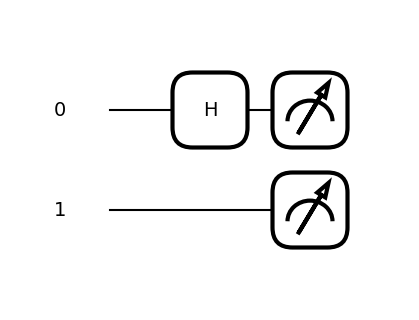

In [ ]:
# Mostrar ambos qubits, incluso si el qubit 1 no tiene compuertas
fig, ax = qml.draw_mpl(
    circuito_2_qubits,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener la matriz completa del circuito
matriz_2 = qml.matrix(
    circuito_2_qubits,
    wire_order=[0, 1]
)()

# Ejecutar el circuito y obtener el estado final
estado_2 = circuito_2_qubits()

print("Matriz del circuito:")
print(np.round(matriz_2, 3))

print("\nVector de estado final:")
print(np.round(estado_2, 3))

Matriz del circuito:
[[ 0.707  0.     0.707  0.   ]
 [ 0.     0.707  0.     0.707]
 [ 0.707  0.    -0.707 -0.   ]
 [ 0.     0.707 -0.    -0.707]]

Vector de estado final:
[0.707+0.j 0.   +0.j 0.707+0.j 0.   +0.j]


### 1.2. Compuertas diferentes en un sistema de tres qubits

Ahora se construye un circuito de tres qubits y se aplica una compuerta diferente a cada uno:

- $R_X(\pi/4)$ al qubit 0.
- $R_Y(3\pi/5)$ al qubit 1.
- Hadamard al qubit 2.

In [ ]:
# Crear un simulador con tres qubits
dev_3 = qml.device("default.qubit", wires=[0, 1, 2])

# Construir el circuito
@qml.qnode(dev_3)
def circuito_3_qubits():

    # Rotación alrededor del eje X en el qubit 0
    qml.RX(np.pi / 4, wires=0)

    # Rotación alrededor del eje Y en el qubit 1
    qml.RY(3 * np.pi / 5, wires=1)

    # Compuerta Hadamard en el qubit 2
    qml.Hadamard(wires=2)

    # Devolver el vector de estado completo
    return qml.state()

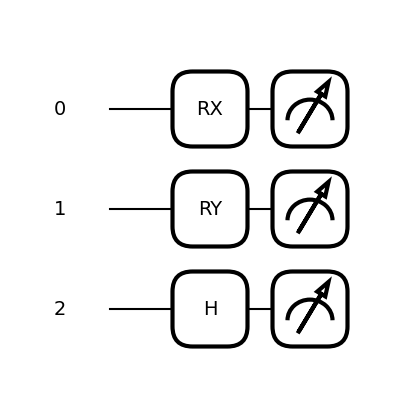

In [ ]:
# Mostrar los tres qubits
fig, ax = qml.draw_mpl(
    circuito_3_qubits,
    wire_order=[0, 1, 2],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener la matriz completa del circuito
matriz_3 = qml.matrix(
    circuito_3_qubits,
    wire_order=[0, 1, 2]
)()

# Ejecutar el circuito y obtener el estado final
estado_3 = circuito_3_qubits()

print("Matriz del circuito:")
print(np.round(matriz_3, 3))

print("\nVector de estado final:")
print(np.round(estado_3, 3))

Matriz del circuito:
[[ 0.384+0.j     0.384+0.j    -0.529+0.j    -0.529+0.j     0.   -0.159j
   0.   -0.159j  0.   +0.219j  0.   +0.219j]
 [ 0.384+0.j    -0.384+0.j    -0.529+0.j     0.529+0.j     0.   -0.159j
   0.   +0.159j  0.   +0.219j  0.   -0.219j]
 [ 0.529+0.j     0.529+0.j     0.384+0.j     0.384+0.j     0.   -0.219j
   0.   -0.219j  0.   -0.159j  0.   -0.159j]
 [ 0.529+0.j    -0.529+0.j     0.384+0.j    -0.384+0.j     0.   -0.219j
   0.   +0.219j  0.   -0.159j  0.   +0.159j]
 [ 0.   -0.159j  0.   -0.159j  0.   +0.219j  0.   +0.219j  0.384+0.j
   0.384+0.j    -0.529+0.j    -0.529+0.j   ]
 [ 0.   -0.159j  0.   +0.159j  0.   +0.219j  0.   -0.219j  0.384+0.j
  -0.384+0.j    -0.529+0.j     0.529+0.j   ]
 [ 0.   -0.219j  0.   -0.219j  0.   -0.159j  0.   -0.159j  0.529+0.j
   0.529+0.j     0.384+0.j     0.384+0.j   ]
 [ 0.   -0.219j  0.   +0.219j  0.   -0.159j  0.   +0.159j  0.529+0.j
  -0.529+0.j     0.384+0.j    -0.384+0.j   ]]

Vector de estado final:
[0.384+0.j    0.384+0.j    0.

## 2. Compuertas de dos qubits

Las compuertas de dos qubits permiten realizar operaciones que dependen del estado de ambos qubits. En esta sección se implementarán la compuerta CNOT, diferentes compuertas controladas y la compuerta SWAP.

### 2.1. Compuerta CNOT

En PennyLane, la compuerta CNOT se implementa con `qml.CNOT(wires=[control, objetivo])`.

En el siguiente ejemplo se prepara el estado $\lvert10\rangle$ aplicando una compuerta $X$ al qubit 0. Como $q_0$ es el control y se encuentra en $\lvert1\rangle$, la CNOT cambia el qubit 1:

$$
\lvert10\rangle
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\lvert11\rangle.
$$

In [ ]:
# Crear un simulador de 2 qubits
dev_cnot_01 = qml.device("default.qubit", wires=[0, 1])

# Construir el circuito
@qml.qnode(dev_cnot_01)
def circuito_cnot_01():

    # Preparar el estado |10>
    qml.PauliX(wires=0)

    # q0 es el control y q1 es el objetivo
    qml.CNOT(wires=[0, 1])

    # Devolver el vector de estado
    return qml.state()

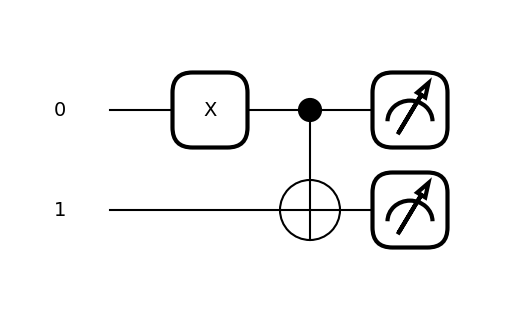

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_cnot_01,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener la matriz del circuito completo
matriz_cnot_01 = qml.matrix(
    circuito_cnot_01,
    wire_order=[0, 1]
)()

# Obtener el estado final
estado_cnot_01 = circuito_cnot_01()

print("Matriz del circuito completo:")
print(np.round(matriz_cnot_01, 3))

print("\nVector de estado final:")
print(np.round(estado_cnot_01, 3))

print("\nEstado final esperado: |11>")

Matriz del circuito completo:
[[0 0 1 0]
 [0 0 0 1]
 [0 1 0 0]
 [1 0 0 0]]

Vector de estado final:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Estado final esperado: |11>


Ahora se invierten las funciones de los qubits. Se prepara el estado $\lvert01\rangle$ y se utiliza $q_1$ como control y $q_0$ como objetivo:

$$
\lvert01\rangle
\xrightarrow{\mathrm{CNOT}_{1\rightarrow0}}
\lvert11\rangle.
$$

In [ ]:
# Crear un simulador de 2 qubits
dev_cnot_10 = qml.device("default.qubit", wires=[0, 1])

# Construir el circuito
@qml.qnode(dev_cnot_10)
def circuito_cnot_10():

    # Preparar el estado |01>
    qml.PauliX(wires=1)

    # q1 es el control y q0 es el objetivo
    qml.CNOT(wires=[1, 0])

    # Devolver el vector de estado
    return qml.state()

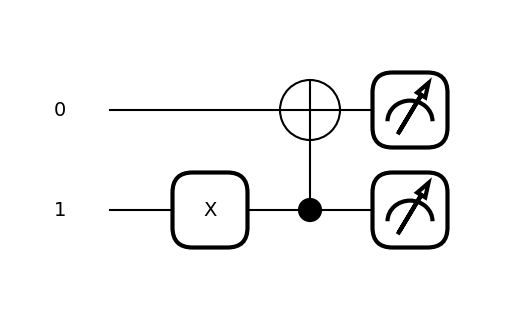

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_cnot_10,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener la matriz del circuito completo
matriz_cnot_10 = qml.matrix(
    circuito_cnot_10,
    wire_order=[0, 1]
)()

# Obtener el estado final
estado_cnot_10 = circuito_cnot_10()

print("Matriz del circuito completo:")
print(np.round(matriz_cnot_10, 3))

print("\nVector de estado final:")
print(np.round(estado_cnot_10, 3))

print("\nEstado final esperado: |11>")

Matriz del circuito completo:
[[0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]

Vector de estado final:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Estado final esperado: |11>


### 2.2. Compuertas controladas

Además de la compuerta $X$, otras operaciones pueden aplicarse de manera controlada. En todos los casos, el primer elemento de `wires` representa el qubit de control y el segundo representa el qubit objetivo.

In [ ]:
# Crear un simulador de 2 qubits
dev_controladas = qml.device("default.qubit", wires=[0, 1])

# Construir un circuito con diferentes compuertas controladas
@qml.qnode(dev_controladas)
def circuito_controladas():

    # Y controlada: q0 es control y q1 es objetivo
    qml.CY(wires=[0, 1])

    # Z controlada: q1 es control y q0 es objetivo
    qml.CZ(wires=[1, 0])

    # X controlada: q0 es control y q1 es objetivo
    qml.CNOT(wires=[0, 1])

    # Hadamard controlada
    qml.CH(wires=[0, 1])

    # Rotación X controlada
    qml.CRX(np.pi / 8, wires=[1, 0])

    # Rotación Z controlada
    qml.CRZ(3 * np.pi / 5, wires=[0, 1])

    # Cambio de fase controlado
    qml.ControlledPhaseShift(
        7 * np.pi / 9,
        wires=[1, 0]
    )

    return qml.state()

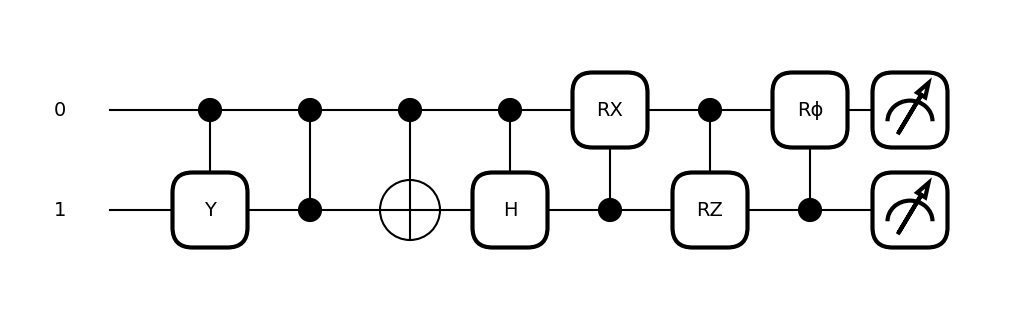

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_controladas,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

#### Compuerta controlada personalizada

PennyLane permite convertir una operación personalizada en una compuerta controlada mediante `qml.ctrl()`.

La siguiente matriz unitaria define la operación personalizada:

$$
U=
\begin{pmatrix}
i & 0\\
0 & 1
\end{pmatrix}.
$$

En el ejemplo, $q_0$ funciona como control y la operación $U$ se aplica sobre $q_1$.

In [ ]:
# Definir la matriz unitaria personalizada
matriz_personalizada = np.array([
    [1j, 0],
    [0, 1]
])

# Definir la operación personalizada
def compuerta_personalizada(wires):
    qml.QubitUnitary(
        matriz_personalizada,
        wires=wires
    )

In [ ]:
# Crear un simulador de 2 qubits
dev_personalizada = qml.device(
    "default.qubit",
    wires=[0, 1]
)

# Construir el circuito
@qml.qnode(dev_personalizada)
def circuito_personalizado():

    # Preparar el qubit de control en |1>
    qml.PauliX(wires=0)

    # q0 controla la operación aplicada sobre q1
    qml.ctrl(
        compuerta_personalizada,
        control=0
    )(wires=1)

    return qml.state()

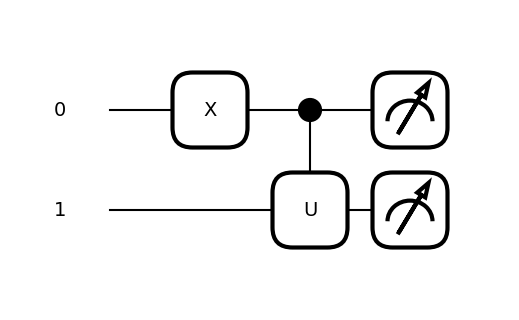

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_personalizado,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener la matriz y el estado final
matriz_controlada = qml.matrix(
    circuito_personalizado,
    wire_order=[0, 1]
)()

estado_controlado = circuito_personalizado()

print("Matriz del circuito completo:")
print(np.round(matriz_controlada, 3))

print("\nVector de estado final:")
print(np.round(estado_controlado, 3))

Matriz del circuito completo:
[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]

Vector de estado final:
[0.+0.j 0.+0.j 0.+1.j 0.+0.j]


### 2.3. Compuerta SWAP

La compuerta SWAP intercambia los estados de dos qubits. Para observarlo, primero se prepara el estado $\lvert10\rangle$:

$$
\lvert10\rangle
\xrightarrow{\mathrm{SWAP}}
\lvert01\rangle.
$$

In [ ]:
# Crear un simulador de 2 qubits
dev_swap = qml.device("default.qubit", wires=[0, 1])

# Circuito que solamente prepara el estado inicial
@qml.qnode(dev_swap)
def preparacion_swap():

    # Preparar el estado |10>
    qml.PauliX(wires=0)

    return qml.state()


# Circuito que prepara el estado y aplica SWAP
@qml.qnode(dev_swap)
def circuito_swap():

    # Preparar el estado |10>
    qml.PauliX(wires=0)

    # Intercambiar los estados de q0 y q1
    qml.SWAP(wires=[0, 1])

    return qml.state()

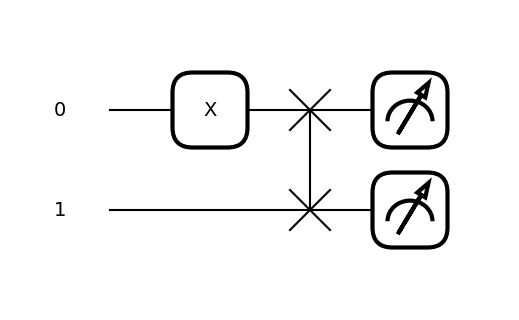

In [ ]:
# Mostrar el circuito completo
fig, ax = qml.draw_mpl(
    circuito_swap,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener los estados antes y después de SWAP
estado_inicial_swap = preparacion_swap()
estado_final_swap = circuito_swap()

print("Estado inicial |10>:")
print(np.round(estado_inicial_swap, 3))

print("\nEstado final |01>:")
print(np.round(estado_final_swap, 3))

Estado inicial |10>:
[0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Estado final |01>:
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]


La compuerta SWAP produce las siguientes transiciones:

$$
\begin{aligned}
\lvert00\rangle &\longrightarrow \lvert00\rangle,\\
\lvert01\rangle &\longrightarrow \lvert10\rangle,\\
\lvert10\rangle &\longrightarrow \lvert01\rangle,\\
\lvert11\rangle &\longrightarrow \lvert11\rangle.
\end{aligned}
$$

Los estados $\lvert00\rangle$ y $\lvert11\rangle$ permanecen iguales porque ambos qubits contienen el mismo valor.

## 3. Compuertas de más de dos qubits

En esta sección se implementan las compuertas Toffoli y Fredkin, además de una operación personalizada con dos qubits de control.

Para `wires=[0,1,2]`, PennyLane escribe los estados en el orden $\lvert q_0q_1q_2\rangle$.

### 3.1. Compuerta Toffoli

La compuerta Toffoli tiene dos qubits de control y un qubit objetivo. En PennyLane se utiliza el orden:

`qml.Toffoli(wires=[control_1, control_2, objetivo])`

En el siguiente circuito, los qubits 1 y 2 son los controles y el qubit 0 es el objetivo. Primero se prepara el estado $\lvert011\rangle$:

$$
\lvert011\rangle
\xrightarrow{\mathrm{Toffoli}_{1,2\rightarrow0}}
\lvert111\rangle.
$$

In [ ]:
# Crear un simulador de 3 qubits
dev_toffoli = qml.device(
    "default.qubit",
    wires=[0, 1, 2]
)

# Circuito que prepara el estado inicial
@qml.qnode(dev_toffoli)
def preparacion_toffoli():

    # Preparar |011>
    qml.PauliX(wires=1)
    qml.PauliX(wires=2)

    return qml.state()


# Circuito completo
@qml.qnode(dev_toffoli)
def circuito_toffoli():

    # Preparar |011>
    qml.PauliX(wires=1)
    qml.PauliX(wires=2)

    # q1 y q2 son controles; q0 es el objetivo
    qml.Toffoli(wires=[1, 2, 0])

    return qml.state()

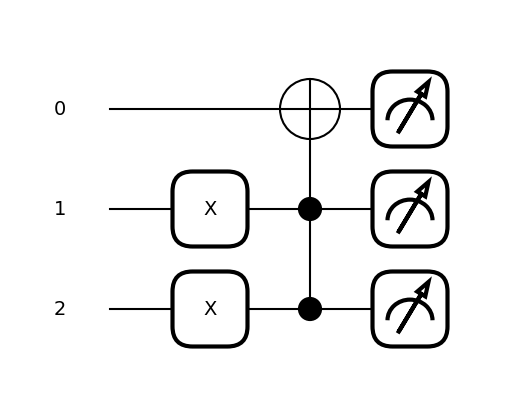

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_toffoli,
    wire_order=[0, 1, 2],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener los estados inicial y final
estado_inicial_toffoli = preparacion_toffoli()
estado_final_toffoli = circuito_toffoli()

print("Estado inicial |011>:")
print(np.round(estado_inicial_toffoli, 3))

print("\nEstado después de Toffoli |111>:")
print(np.round(estado_final_toffoli, 3))

Estado inicial |011>:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Estado después de Toffoli |111>:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]


Los dos controles se encuentran en $\lvert1\rangle$, por lo que la compuerta Toffoli aplica una compuerta $X$ al qubit 0. Si cualquiera de los controles estuviera en $\lvert0\rangle$, el qubit 0 permanecería sin cambios.

### 3.2. Compuerta Fredkin

La compuerta Fredkin, también llamada SWAP controlada, tiene un qubit de control y dos qubits objetivo. En PennyLane se utiliza el orden:

`qml.CSWAP(wires=[control, objetivo_1, objetivo_2])`

En el siguiente circuito, $q_2$ es el control y los estados de $q_0$ y $q_1$ se intercambian:

$$
\lvert011\rangle
\xrightarrow{\mathrm{CSWAP}_{2\rightarrow0,1}}
\lvert101\rangle.
$$

In [ ]:
# Crear un simulador de 3 qubits
dev_fredkin = qml.device(
    "default.qubit",
    wires=[0, 1, 2]
)

# Circuito que prepara el estado inicial
@qml.qnode(dev_fredkin)
def preparacion_fredkin():

    # Preparar |011>
    qml.PauliX(wires=1)
    qml.PauliX(wires=2)

    return qml.state()


# Circuito completo
@qml.qnode(dev_fredkin)
def circuito_fredkin():

    # Preparar |011>
    qml.PauliX(wires=1)
    qml.PauliX(wires=2)

    # q2 es el control; q0 y q1 son los objetivos
    qml.CSWAP(wires=[2, 0, 1])

    return qml.state()

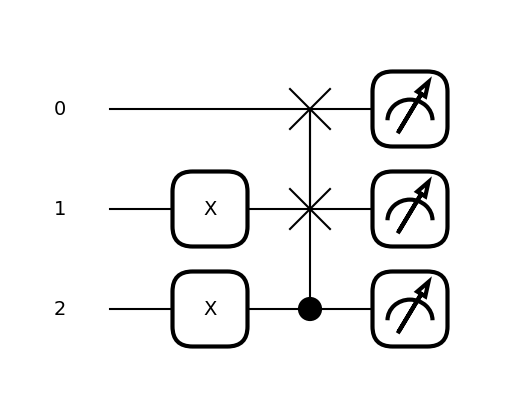

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_fredkin,
    wire_order=[0, 1, 2],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener los estados inicial y final
estado_inicial_fredkin = preparacion_fredkin()
estado_final_fredkin = circuito_fredkin()

print("Estado inicial |011>:")
print(np.round(estado_inicial_fredkin, 3))

print("\nEstado después de Fredkin |101>:")
print(np.round(estado_final_fredkin, 3))

Estado inicial |011>:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Estado después de Fredkin |101>:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]


Como el qubit de control $q_2$ se encuentra en $\lvert1\rangle$, la compuerta intercambia los estados de $q_0$ y $q_1$. Si $q_2$ estuviera en $\lvert0\rangle$, el intercambio no se realizaría.

### 3.3. Compuerta controlada personalizada

PennyLane permite utilizar `qml.ctrl()` para agregar uno o varios controles a una operación.

La operación personalizada del siguiente ejemplo aplica una compuerta $X$ al qubit 1 y una compuerta Hadamard al qubit 2. La operación completa está controlada por los qubits 0 y 3.

In [ ]:
# Definir la operación que actuará sobre los qubits objetivo
def operacion_personalizada(wires):

    # Primer qubit objetivo
    qml.PauliX(wires=wires[0])

    # Segundo qubit objetivo
    qml.Hadamard(wires=wires[1])

In [ ]:
# Crear un simulador de 4 qubits
dev_personalizada_4q = qml.device(
    "default.qubit",
    wires=[0, 1, 2, 3]
)

# Construir el circuito
@qml.qnode(dev_personalizada_4q)
def circuito_personalizado_4q():

    # Preparar los dos controles en |1>
    qml.PauliX(wires=0)
    qml.PauliX(wires=3)

    # q0 y q3 son los controles
    # q1 y q2 son los objetivos
    qml.ctrl(
        operacion_personalizada,
        control=[0, 3]
    )(wires=[1, 2])

    return qml.state()

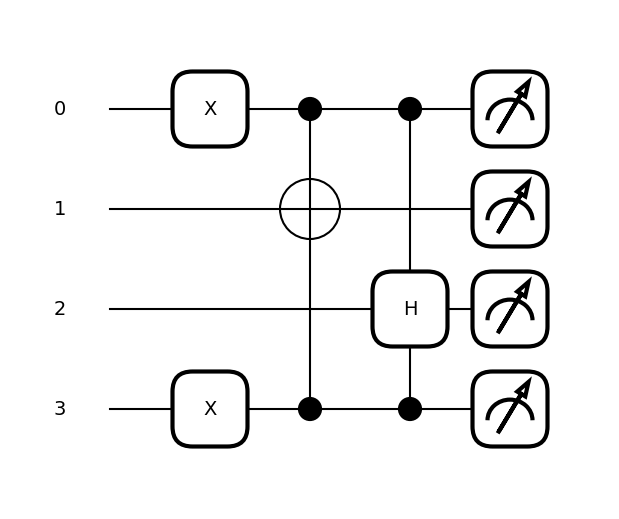

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_personalizado_4q,
    wire_order=[0, 1, 2, 3],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el estado final
estado_personalizado_4q = circuito_personalizado_4q()

print("Vector de estado final:")
print(np.round(estado_personalizado_4q, 3))

Vector de estado final:
[0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.707+0.j
 0.   +0.j 0.707+0.j]


La operación personalizada se aplica únicamente cuando los dos qubits de control, $q_0$ y $q_3$, se encuentran en $\lvert1\rangle$. Si uno de ellos está en $\lvert0\rangle$, las compuertas $X$ y $H$ no se aplican sobre los qubits objetivo.

## 4. Estados de Bell

Los cuatro estados de Bell son

$$
\lvert\Phi^+\rangle
=
\frac{\lvert00\rangle+\lvert11\rangle}{\sqrt{2}},
\qquad
\lvert\Phi^-\rangle
=
\frac{\lvert00\rangle-\lvert11\rangle}{\sqrt{2}},
$$

$$
\lvert\Psi^+\rangle
=
\frac{\lvert01\rangle+\lvert10\rangle}{\sqrt{2}},
\qquad
\lvert\Psi^-\rangle
=
\frac{\lvert01\rangle-\lvert10\rangle}{\sqrt{2}}.
$$



### 4.1. Estado $\lvert\Phi^+\rangle$

Se aplica una compuerta Hadamard al qubit 0 y después una CNOT con $q_0$ como control:

$$
\lvert00\rangle
\xrightarrow{H_0}
\frac{\lvert00\rangle+\lvert10\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{\lvert00\rangle+\lvert11\rangle}{\sqrt{2}}
=
\lvert\Phi^+\rangle.
$$

In [ ]:
# Crear el simulador
dev_bell = qml.device(
    "default.qubit",
    wires=[0, 1]
)

# Construir el estado de Bell |Φ+>
@qml.qnode(dev_bell)
def circuito_phi_mas():

    # Crear una superposición en q0
    qml.Hadamard(wires=0)

    # Entrelazar q0 y q1
    qml.CNOT(wires=[0, 1])

    return qml.state()

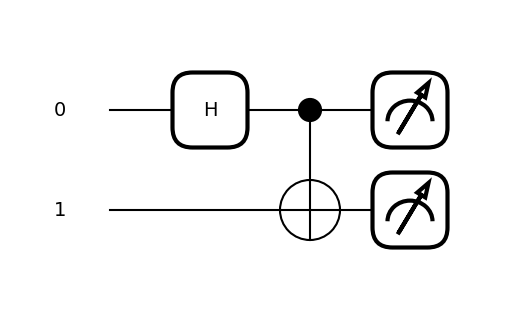

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_phi_mas,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el estado final
estado_phi_mas = circuito_phi_mas()

print("Estado |Φ+> en forma de vector:")
print(np.round(estado_phi_mas, 3))

print("\nEstado esperado:")
print("(|00> + |11>) / √2")

Estado |Φ+> en forma de vector:
[0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]

Estado esperado:
(|00> + |11>) / √2


### 4.2. Estado $\lvert\Phi^-\rangle$

Primero se prepara el qubit 0 en $\lvert1\rangle$. Después se aplican una compuerta Hadamard y una CNOT:

$$
\lvert00\rangle
\xrightarrow{X_0}
\lvert10\rangle
\xrightarrow{H_0}
\frac{\lvert00\rangle-\lvert10\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{\lvert00\rangle-\lvert11\rangle}{\sqrt{2}}
=
\lvert\Phi^-\rangle.
$$

In [ ]:
# Construir el estado de Bell |Φ->
@qml.qnode(dev_bell)
def circuito_phi_menos():

    # Preparar q0 en |1>
    qml.PauliX(wires=0)

    # Crear una superposición con signo negativo
    qml.Hadamard(wires=0)

    # Entrelazar q0 y q1
    qml.CNOT(wires=[0, 1])

    return qml.state()

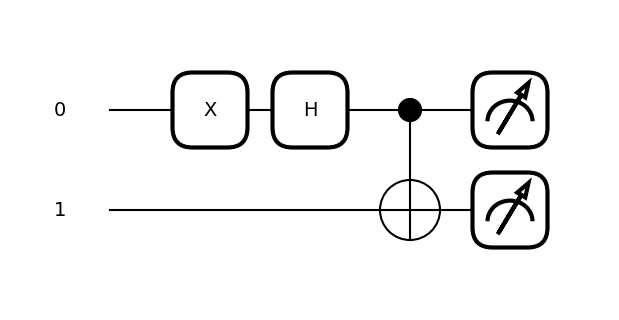

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_phi_menos,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el estado final
estado_phi_menos = circuito_phi_menos()

print("Estado |Φ-> en forma de vector:")
print(np.round(estado_phi_menos, 3))

print("\nEstado esperado:")
print("(|00> - |11>) / √2")

Estado |Φ-> en forma de vector:
[ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]

Estado esperado:
(|00> - |11>) / √2


### 4.3. Estado $\lvert\Psi^+\rangle$

Primero se prepara el qubit 1 en $\lvert1\rangle$. Después se aplican una compuerta Hadamard al qubit 0 y una CNOT:

$$
\lvert00\rangle
\xrightarrow{X_1}
\lvert01\rangle
\xrightarrow{H_0}
\frac{\lvert01\rangle+\lvert11\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{\lvert01\rangle+\lvert10\rangle}{\sqrt{2}}
=
\lvert\Psi^+\rangle.
$$

In [ ]:
# Construir el estado de Bell |Ψ+>
@qml.qnode(dev_bell)
def circuito_psi_mas():

    # Preparar q1 en |1>
    qml.PauliX(wires=1)

    # Crear una superposición en q0
    qml.Hadamard(wires=0)

    # Entrelazar q0 y q1
    qml.CNOT(wires=[0, 1])

    return qml.state()

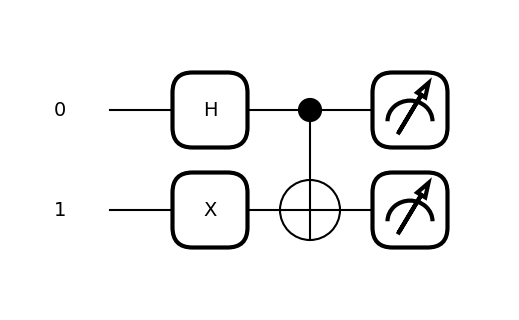

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_psi_mas,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el estado final
estado_psi_mas = circuito_psi_mas()

print("Estado |Ψ+> en forma de vector:")
print(np.round(estado_psi_mas, 3))

print("\nEstado esperado:")
print("(|01> + |10>) / √2")

Estado |Ψ+> en forma de vector:
[0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]

Estado esperado:
(|01> + |10>) / √2


### 4.4. Estado $\lvert\Psi^-\rangle$

Se prepara el estado $\lvert01\rangle$ aplicando una compuerta $X$ al qubit 1. Después se utilizan las compuertas Hadamard y $Z$ sobre el qubit 0, seguidas de una CNOT:

$$
\lvert00\rangle
\xrightarrow{X_1}
\lvert01\rangle
\xrightarrow{H_0}
\frac{\lvert01\rangle+\lvert11\rangle}{\sqrt{2}}
\xrightarrow{Z_0}
\frac{\lvert01\rangle-\lvert11\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{\lvert01\rangle-\lvert10\rangle}{\sqrt{2}}
=
\lvert\Psi^-\rangle.
$$

In [ ]:
# Construir el estado de Bell |Ψ->
@qml.qnode(dev_bell)
def circuito_psi_menos():

    # Preparar el estado |01>
    qml.PauliX(wires=1)

    # Crear una superposición en q0
    qml.Hadamard(wires=0)

    # Cambiar el signo de la componente con q0 = 1
    qml.PauliZ(wires=0)

    # Entrelazar q0 y q1
    qml.CNOT(wires=[0, 1])

    return qml.state()

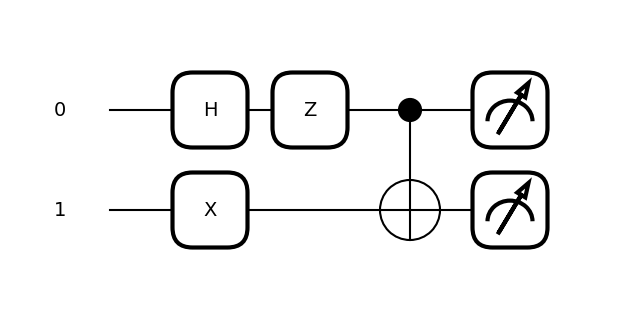

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_psi_menos,
    wire_order=[0, 1],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el estado final
estado_psi_menos = circuito_psi_menos()

print("Estado |Ψ-> en forma de vector:")
print(np.round(estado_psi_menos, 3))

print("\nEstado en notación ket:")
print("(|01> - |10>) / √2")

Estado |Ψ-> en forma de vector:
[ 0.   +0.j  0.707+0.j -0.707+0.j -0.   +0.j]

Estado en notación ket:
(|01> - |10>) / √2


### 4.5. Vectores de Bloch de un estado entrelazado

En un estado de Bell, el sistema completo se encuentra en un estado puro, pero cada qubit considerado individualmente se encuentra en un estado mixto.

Para comprobarlo, se calculan las componentes $X$, $Y$ y $Z$ del vector de Bloch de cada qubit del estado $\lvert\Phi^+\rangle$.

In [ ]:
# Calcular las componentes del vector de Bloch de cada qubit
@qml.qnode(dev_bell)
def vectores_bloch_phi_mas():

    # Preparar |Φ+>
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])

    return (
        qml.expval(qml.PauliX(0)),
        qml.expval(qml.PauliY(0)),
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliX(1)),
        qml.expval(qml.PauliY(1)),
        qml.expval(qml.PauliZ(1))
    )

In [ ]:
# Ejecutar el circuito
componentes_bloch = np.array(
    vectores_bloch_phi_mas()
)

# Separar las componentes de cada qubit
bloch_q0 = componentes_bloch[:3]
bloch_q1 = componentes_bloch[3:]

print("Vector de Bloch de q0:")
print(np.round(bloch_q0, 3))

print("\nVector de Bloch de q1:")
print(np.round(bloch_q1, 3))

Vector de Bloch de q0:
[0. 0. 0.]

Vector de Bloch de q1:
[0. 0. 0.]


Para ambos qubits se obtiene

$$
\vec r=(0,0,0).
$$

El vector aparece en el centro de la esfera de Bloch porque cada qubit, considerado de manera individual, se encuentra en un estado completamente mixto. El entrelazamiento está contenido en las correlaciones del sistema completo y no en el estado individual de alguno de los qubits.

## 5. Simulación y medición

Se construirá el estado GHZ de tres qubits:

$$
\lvert\mathrm{GHZ}\rangle
=
\frac{\lvert000\rangle+\lvert111\rangle}{\sqrt{2}}.
$$

Al medir este estado en la base computacional, solamente pueden obtenerse los resultados $\lvert000\rangle$ y $\lvert111\rangle$, cada uno con probabilidad teórica de $1/2$.

### 5.1. Construcción del estado GHZ

El estado se construye aplicando una compuerta Hadamard al qubit 0 y utilizando posteriormente ese qubit como control de dos compuertas CNOT:

$$
\lvert000\rangle
\xrightarrow{H_0}
\frac{\lvert000\rangle+\lvert100\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{\lvert000\rangle+\lvert110\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow2}}
\frac{\lvert000\rangle+\lvert111\rangle}{\sqrt{2}}.
$$

In [ ]:
# Crear un simulador analítico de 3 qubits
dev_ghz = qml.device(
    "default.qubit",
    wires=[0, 1, 2]
)

# Construir el circuito GHZ
@qml.qnode(dev_ghz)
def circuito_ghz():

    # Crear una superposición en q0
    qml.Hadamard(wires=0)

    # Entrelazar q0 con q1
    qml.CNOT(wires=[0, 1])

    # Entrelazar q0 con q2
    qml.CNOT(wires=[0, 2])

    return qml.state()

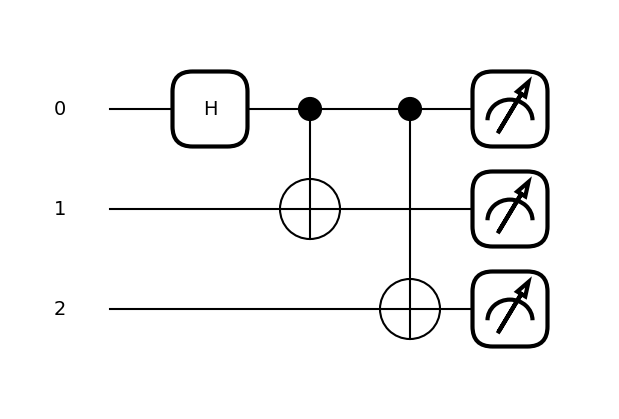

In [ ]:
# Mostrar el circuito
fig, ax = qml.draw_mpl(
    circuito_ghz,
    wire_order=[0, 1, 2],
    show_all_wires=True
)()

plt.show()

In [ ]:
# Obtener el vector de estado
estado_ghz = circuito_ghz()

print("Estado GHZ en forma de vector:")
print(np.round(estado_ghz, 3))

print("\nEstado en notación ket:")
print("(|000> + |111>) / √2")

Estado GHZ en forma de vector:
[0.707+0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
 0.707+0.j]

Estado en notación ket:
(|000> + |111>) / √2


### 5.2. Probabilidades exactas

Con `qml.probs()` se calculan directamente las probabilidades teóricas de todos los resultados posibles. Esta simulación es analítica y no utiliza shots.

In [ ]:
# Circuito analítico que devuelve probabilidades
@qml.qnode(dev_ghz)
def probabilidades_ghz():

    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[0, 2])

    return qml.probs(wires=[0, 1, 2])

In [ ]:
# Estados posibles de 3 qubits
estados_base = [
    "000", "001", "010", "011",
    "100", "101", "110", "111"
]

# Calcular las probabilidades exactas
probabilidades = probabilidades_ghz()

for estado, probabilidad in zip(estados_base, probabilidades):
    print(
        f"P({estado}) = "
        f"{float(probabilidad):.3f}"
    )

P(000) = 0.500
P(001) = 0.000
P(010) = 0.000
P(011) = 0.000
P(100) = 0.000
P(101) = 0.000
P(110) = 0.000
P(111) = 0.500


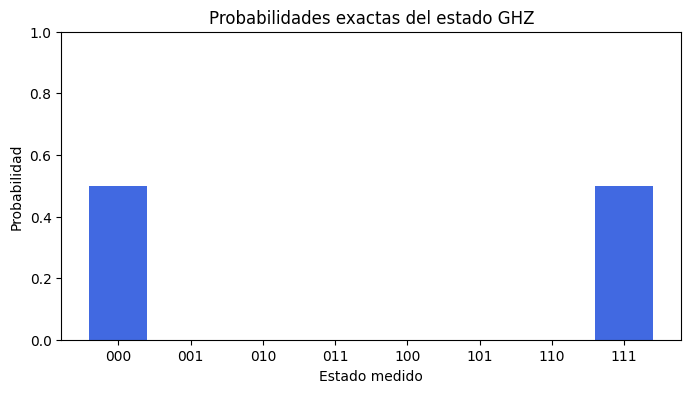

In [ ]:
# Graficar las probabilidades exactas
plt.figure(figsize=(8, 4))

plt.bar(
    estados_base,
    probabilidades,
    color="royalblue"
)

plt.xlabel("Estado medido")
plt.ylabel("Probabilidad")
plt.title("Probabilidades exactas del estado GHZ")
plt.ylim(0, 1)

plt.show()

Las únicas probabilidades diferentes de cero son

$$
P(000)=\frac{1}{2},
\qquad
P(111)=\frac{1}{2}.
$$

Los demás estados tienen probabilidad cero.

### 5.3. Simulación con shots

Un shot representa una ejecución y medición del circuito. Al utilizar un número finito de shots, PennyLane devuelve frecuencias obtenidas mediante muestreo en lugar de las probabilidades exactas.

A diferencia de Qiskit, no es necesario crear registros clásicos ni agregar instrucciones de medición al circuito. El tipo de medición se especifica directamente en el valor devuelto por el QNode.

In [ ]:
# Función para crear y ejecutar el circuito
# con un número determinado de shots
def simular_ghz(shots):

    # Crear un simulador con shots finitos
    dev = qml.device(
        "default.qubit",
        wires=[0, 1, 2],
        shots=shots
    )

    # Construir el circuito
    @qml.qnode(dev)
    def circuito():

        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[0, 2])

        # Contar los resultados obtenidos
        return qml.counts(wires=[0, 1, 2])

    return circuito()

Primero se ejecuta el circuito utilizando 1024 shots.

In [ ]:
# Ejecutar el circuito 1024 veces
conteos_1024 = simular_ghz(shots=1024)

print("Resultados con 1024 shots:")
print(conteos_1024)

Resultados con 1024 shots:
{np.str_('000'): np.int64(472), np.str_('111'): np.int64(552)}


/usr/local/lib/python3.13/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [ ]:
# Ejecutar el circuito 1024 veces
conteos_1024 = simular_ghz(shots=1024)

print("Resultados con 1024 shots:")
print(conteos_1024)

Resultados con 1024 shots:
{np.str_('000'): np.int64(498), np.str_('111'): np.int64(526)}


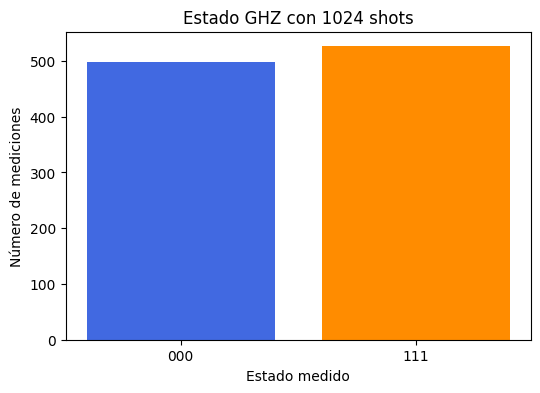

In [ ]:
# Extraer los conteos de cada estado
conteo_000 = conteos_1024.get("000", 0)
conteo_111 = conteos_1024.get("111", 0)

# Graficar los resultados
plt.figure(figsize=(6, 4))

plt.bar(
    ["000", "111"],
    [conteo_000, conteo_111],
    color=["royalblue", "darkorange"]
)

plt.xlabel("Estado medido")
plt.ylabel("Número de mediciones")
plt.title("Estado GHZ con 1024 shots")

plt.show()

Ahora se repite la simulación utilizando 256 shots.

In [ ]:
# Ejecutar el circuito 256 veces
conteos_256 = simular_ghz(shots=256)

print("Resultados con 256 shots:")
print(conteos_256)

Resultados con 256 shots:
{np.str_('000'): np.int64(123), np.str_('111'): np.int64(133)}


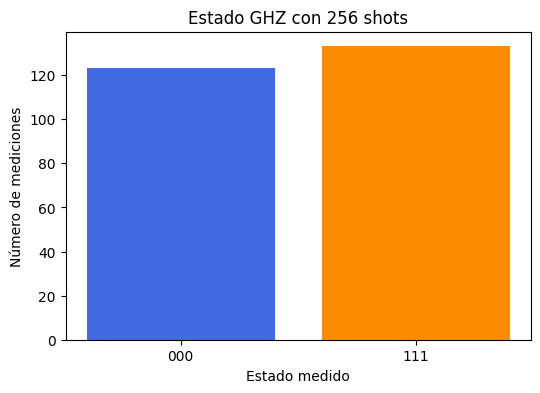

In [ ]:
# Extraer los conteos de cada estado
conteo_000 = conteos_256.get("000", 0)
conteo_111 = conteos_256.get("111", 0)

# Graficar los resultados
plt.figure(figsize=(6, 4))

plt.bar(
    ["000", "111"],
    [conteo_000, conteo_111],
    color=["royalblue", "darkorange"]
)

plt.xlabel("Estado medido")
plt.ylabel("Número de mediciones")
plt.title("Estado GHZ con 256 shots")

plt.show()

Los conteos de $\lvert000\rangle$ y $\lvert111\rangle$ no tienen que ser exactamente iguales. Los shots representan una muestra aleatoria de la distribución teórica.

Al aumentar el número de shots, las frecuencias relativas generalmente se aproximan mejor a las probabilidades teóricas:

$$
\frac{N(000)}{N}
\longrightarrow
\frac{1}{2},
\qquad
\frac{N(111)}{N}
\longrightarrow
\frac{1}{2}.
$$

### 5.4. Comparación entre probabilidades y frecuencias

Las probabilidades exactas pueden compararse con las frecuencias relativas obtenidas mediante shots.

In [ ]:
# Calcular frecuencias relativas
frecuencia_000_256 = conteos_256.get("000", 0) / 256
frecuencia_111_256 = conteos_256.get("111", 0) / 256

frecuencia_000_1024 = conteos_1024.get("000", 0) / 1024
frecuencia_111_1024 = conteos_1024.get("111", 0) / 1024

print("Probabilidades teóricas:")
print("P(000) = 0.500")
print("P(111) = 0.500")

print("\nFrecuencias con 256 shots:")
print(f"f(000) = {frecuencia_000_256:.3f}")
print(f"f(111) = {frecuencia_111_256:.3f}")

print("\nFrecuencias con 1024 shots:")
print(f"f(000) = {frecuencia_000_1024:.3f}")
print(f"f(111) = {frecuencia_111_1024:.3f}")

Probabilidades teóricas:
P(000) = 0.500
P(111) = 0.500

Frecuencias con 256 shots:
f(000) = 0.480
f(111) = 0.520

Frecuencias con 1024 shots:
f(000) = 0.486
f(111) = 0.514


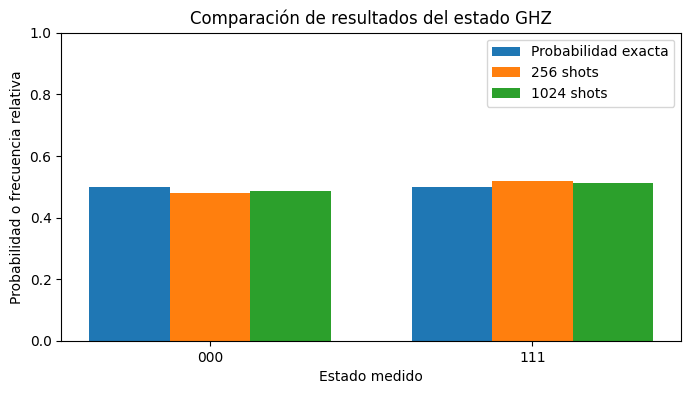

In [ ]:
# Posiciones de las barras
x = np.arange(2)
ancho = 0.25

# Crear la gráfica comparativa
plt.figure(figsize=(8, 4))

plt.bar(
    x - ancho,
    [0.5, 0.5],
    width=ancho,
    label="Probabilidad exacta"
)

plt.bar(
    x,
    [frecuencia_000_256, frecuencia_111_256],
    width=ancho,
    label="256 shots"
)

plt.bar(
    x + ancho,
    [frecuencia_000_1024, frecuencia_111_1024],
    width=ancho,
    label="1024 shots"
)

plt.xticks(x, ["000", "111"])
plt.xlabel("Estado medido")
plt.ylabel("Probabilidad o frecuencia relativa")
plt.title("Comparación de resultados del estado GHZ")
plt.ylim(0, 1)
plt.legend()

plt.show()

### 5.5. Valores esperados

El valor esperado de un observable $A$ para un estado $\lvert\psi\rangle$ se define como

$$
\langle A\rangle
=
\langle\psi\lvert A\rvert\psi\rangle.
$$

Para el estado GHZ, el valor esperado de $Z$ sobre un solo qubit es cero porque los resultados 0 y 1 tienen la misma probabilidad. Sin embargo, los qubits presentan correlaciones perfectas.

In [ ]:
# Circuito para calcular valores esperados
@qml.qnode(dev_ghz)
def valores_esperados_ghz():

    # Preparar el estado GHZ
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[0, 2])

    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(
            qml.PauliZ(0) @ qml.PauliZ(1)
        ),
        qml.expval(
            qml.PauliZ(0) @ qml.PauliZ(2)
        )
    )

In [ ]:
# Calcular los valores esperados
resultados_esperados = valores_esperados_ghz()

print("<Z₀> =", np.round(resultados_esperados[0], 3))
print("<Z₁> =", np.round(resultados_esperados[1], 3))
print("<Z₂> =", np.round(resultados_esperados[2], 3))

print(
    "\n<Z₀Z₁> =",
    np.round(resultados_esperados[3], 3)
)

print(
    "<Z₀Z₂> =",
    np.round(resultados_esperados[4], 3)
)

<Z₀> = 0.0
<Z₁> = 0.0
<Z₂> = 0.0

<Z₀Z₁> = 1.0
<Z₀Z₂> = 1.0


Los valores individuales son

$$
\langle Z_0\rangle
=
\langle Z_1\rangle
=
\langle Z_2\rangle
=
0.
$$

En cambio,

$$
\langle Z_0Z_1\rangle
=
\langle Z_0Z_2\rangle
=
1.
$$

Cada qubit produce individualmente resultados aleatorios, pero los tres qubits siempre se miden de manera correlacionada: todos aparecen como 0 o todos aparecen como 1.